In [ ]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# 1. Define States and Observations
states = ["Sunny", "Rainy", "Cloudy"]
observations = ["Happy", "Sad"]

In [ ]:
# 2. Create Mapping
state_map = {
    "Sunny": 0,
    "Rainy": 1,
    "Cloudy": 2
}

In [ ]:
# 3. Emission Probabilities

# Probability of observation given state

emission_prob = {
    "Sunny": {
        "Happy": 0.8,
        "Sad": 0.2
    },

    "Rainy": {
        "Happy": 0.3,
        "Sad": 0.7
    },

    "Cloudy": {
        "Happy": 0.5,
        "Sad": 0.5
    }
}

In [ ]:
# 4. Example Dataset

obs_sequence = ["Happy", "Sad", "Happy", "Happy", "Sad"]

# Actual weather states
true_states = ["Sunny", "Rainy", "Cloudy", "Sunny", "Rainy"]


In [ ]:
# 5. Simple Prediction Logic
# Choose the state having highest probability
# for each observation

predicted_states = []

for obs in obs_sequence:

    best_state = None
    highest_prob = 0

    for state in states:

        prob = emission_prob[state][obs]

        if prob > highest_prob:

            highest_prob = prob
            best_state = state

    predicted_states.append(best_state)


In [ ]:
# 6. Convert States to Numbers
true_labels = [state_map[s] for s in true_states]
predicted_labels = [state_map[s] for s in predicted_states]

In [ ]:
# 7. Evaluation Metrics
accuracy = accuracy_score(true_labels, predicted_labels)
cm = confusion_matrix(true_labels, predicted_labels)
print("Observations:", obs_sequence)
print("True States:", true_states)
print("Predicted States:", predicted_states)
print("Accuracy:", accuracy)

Observations: ['Happy', 'Sad', 'Happy', 'Happy', 'Sad']
True States: ['Sunny', 'Rainy', 'Cloudy', 'Sunny', 'Rainy']
Predicted States: ['Sunny', 'Rainy', 'Sunny', 'Sunny', 'Rainy']
Accuracy: 0.8


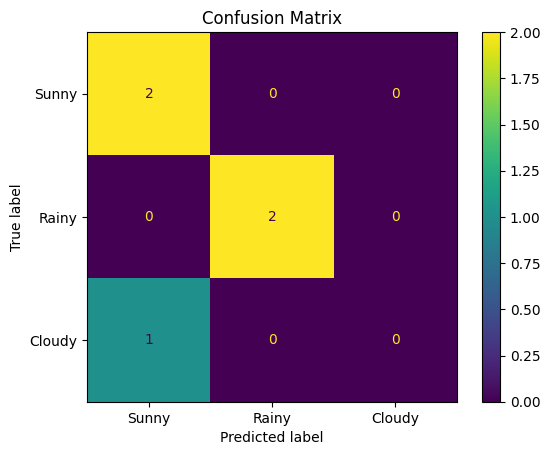

In [ ]:
# 8. Confusion Matrix Visualization
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=states
)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

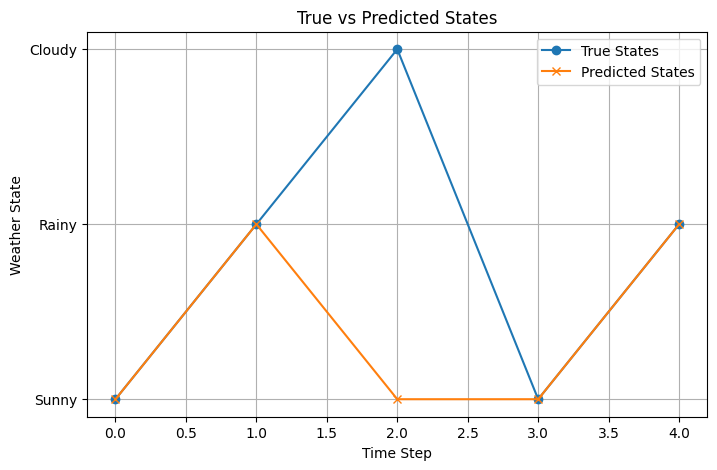

In [ ]:
# 9. True vs Predicted Visualization
plt.figure(figsize=(8,5))
plt.plot(
    true_labels,
    marker='o',
    label='True States'
)
plt.plot(
    predicted_labels,
    marker='x',
    label='Predicted States'
)
plt.yticks(range(len(states)), states)
plt.xlabel("Time Step")
plt.ylabel("Weather State")
plt.title("True vs Predicted States")
plt.legend()
plt.grid()